# **(ADD THE NOTEBOOK NAME HERE)**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
#last code line generated by Gemini to allow matplotlib plots to be seen

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [3]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\OneDrive\\Code Institute\\Health-Insurance-Analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\world\\OneDrive\\Code Institute\\Health-Insurance-Analysis'

# Loading and cleaning the data

Section 1 content

Write code to read insurance.csv file and save to the variable df

In [22]:
#code format taken from LMS visualisations modules
df = pd.read_csv('data/raw data/insurance.csv')

Inspect the data: check shape, check data types in each column, look for missing values and duplicates, spot outliers.

Shape Check:

In [23]:
#check how many rows and columns
#code from my notes from Rory's lesson
df.shape

(1338, 7)

In [24]:
#check the first five rows to see if the data loaded correctly
#code from my notes from Rory's lesson
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Data Type Check:

In [25]:
#check the data type in each column to see if there is any rogue text
#code from my notes from Rory's lesson
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Age, bmi, children and charges all have numbers, so no rogue text is present in those columns. We will check for negative numbers later on. Smoker, sex and region are object types, so we need to see which objects they contain to check they are clean.

Run value counts to see what is in each of the columns with object as their data type.

In [26]:
#code taken from Gemini
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [27]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [28]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

The above results show that there are no random values in the 3 object columns we checked.

Missing Values Check:

In [29]:
#check for any missing values
#code from my notes from Rory's lesson
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values.

Duplicates Check:

In [30]:
#Gemini suggested chaining to see how many duplicates are present
df.duplicated().sum()

1

There is one duplicate. As charges aand bmi are floats with several decimal places, this could be a duplicate, not just a coincidence. Check the 2 identical rows before deciding whether or not to remove it.

In [31]:
#code generated using Gemini guidance for structure and keep=False
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Bmi is identical to 2 decimal places and charges is identical down to 4 decimal places! We will treat this as a duplicate and remove the duplicated row.

In [32]:
#save the cleaned version to a new variable
#this code will keep the first instance and drop the second duplicated one. 'drop_duplicates()' was taken from Gemini.
df_cleaned = df.drop_duplicates()

In [33]:
#check the shape to see if one row was dropped
df_cleaned.shape

(1337, 7)

This is the expected output. One row was dropped.

Outlier Check:

In [34]:
#code from my notes in Rory's lesson
df_cleaned.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


From this output we can see that all columns have 1337 rows, confirming the duplicate row was dropped in the second instance and no new rows were added. We can see the mean, minimum and maximum values for all columns. There may be some outliers. The max bmi sits a little further from the 75th percentile and the max charges are much higher than the 75th percentile. These would be our outliers. We could use a box plot to show this. We can also see that the columns with data types int64 and float from earlier do not have any negative numbers. We can conclude that the data looks accurate and is clean.

Save the cleaned data as a csv file

In [37]:
#code taken from Jayne Lawley in Project 1
df_cleaned.to_csv('data/cleaned data/insurance_cleaned.csv', index=False)

# Visualising Charges Outliers

Draw a boxplot for charges to see outliers

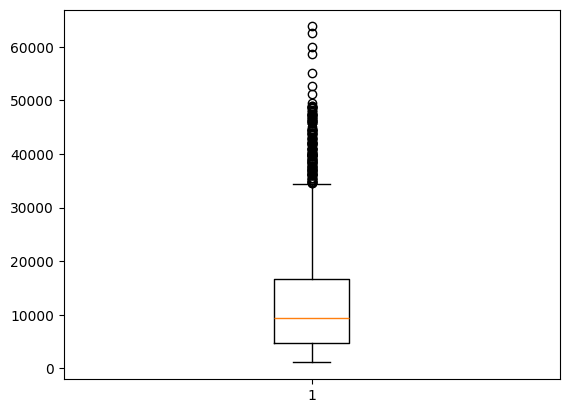

In [ ]:
#code structure from LMS modules
plt.boxplot(df_cleaned['charges'])
plt.show()

From this boxplot, we can see that there are a significant number of outliers. We can assume that they are not accidental or typing errors, but rather they represent real data. E.g. one reason for these outlier individuals having higher charges than the majority of people in the dataset could be due to major surgeries. We will not exclude any of these charges for the following charts and analyses as that would be a misrepresentation of the data and lower the charges.  

---

# Visualisations

Hypotheses:

Age: Medical charges increase with age.

Smoking: Patients who smoke have significantly higher medical charges than non-smokers.

BMI: Patients with higher bmi generally have higher medical charges. 

Region & Children: A patient's geographic region and the number of children they have will impact their average medical charges.

### Age vs Charges:

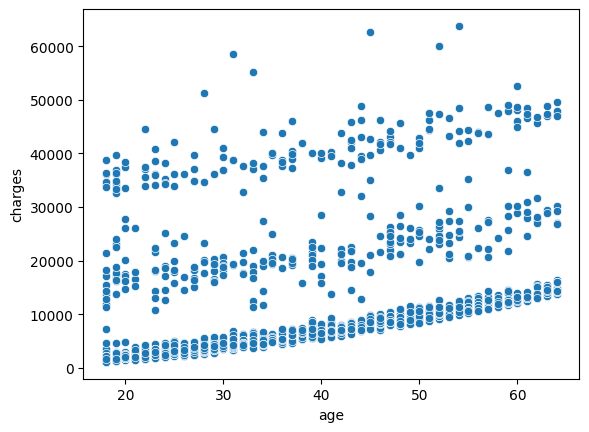

In [39]:
#code structure from LMS modules
sns.scatterplot(data=df_cleaned, x='age', y='charges')
plt.show()

We see 3 trends. Let's see what other variables could be contributing to the trends we see.

### Age vs Charges coloured by Smoker:

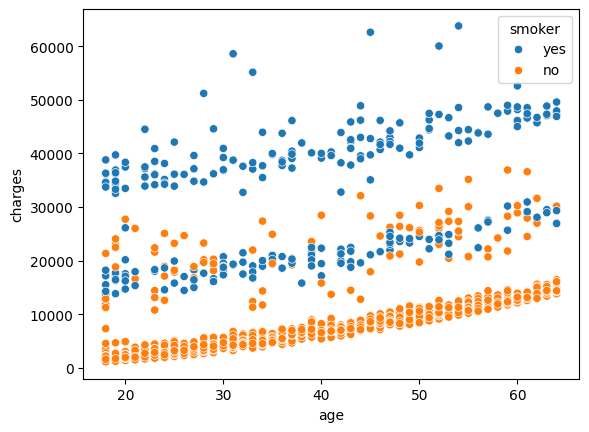

In [40]:
sns.scatterplot(data=df_cleaned, x='age', y='charges', hue='smoker')
plt.show()

We can see that smokers have the highest charges across all ages. The general trend in the smoking and non smoking groups is that insurance costs increase with age.
However, there is still an overlap in many data points for smokers and non smokers. Given time, I would like to explore this further.
PUT IN README: I used scatter plots for age and bmi charts as they contain continuous data and I want to check for correlations and groups

### BMI vs Charges coloured by Smoker:

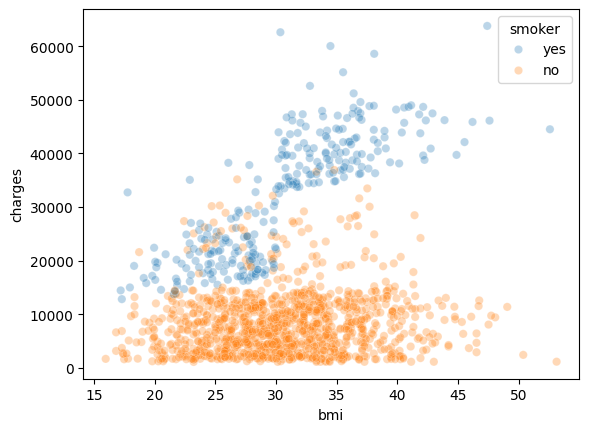

In [49]:
sns.scatterplot(data=df_cleaned, x='bmi', y='charges', hue='smoker', alpha=0.3)
plt.show()

This scatterplot shows that smokers with the same or similar bmi to non smokers have significantly higher medical charges. There is also a difference in patter in the smokers and non smokers groups. There is a sharp increase in charges when the bmi crosses 30 in smokers, but such a pattern is not seen in the non smokers group where charges stay relatively stable. 

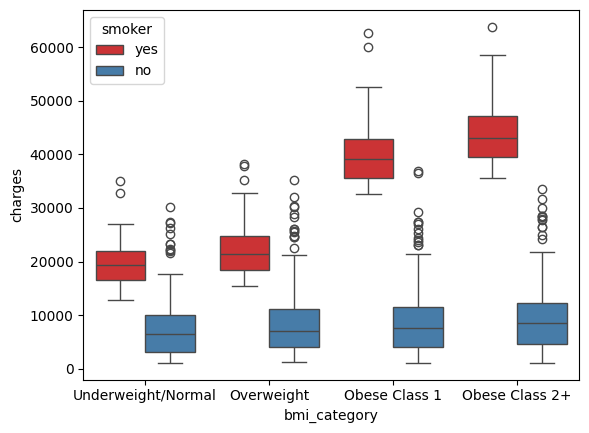

In [ ]:
#code completely generated by Gemini
df_copy = df_cleaned.copy()

df_copy['bmi_category'] = pd.cut(
    df_copy['bmi'],
    bins=[0, 25, 30, 35, float('inf')],
    labels=['Underweight/Normal', 'Overweight', 'Obese Class 1', 'Obese Class 2+']
)

sns.boxplot(data=df_copy, x='bmi_category', y='charges', hue='smoker', palette='Set1')
plt.show()

This boxplot grouped bmi into separate categories to clearly see where the median lies within those categories and use that to compare smokers charges to that of non smokers. It shows us that there is a very slight median increase in charges as bmi increases in non smokers.

### Sex vs Average Charges:

In [ ]:
#code generated with hints and fixes from Gemini
avg_charges = df_cleaned.groupby('sex')['charges'].mean()

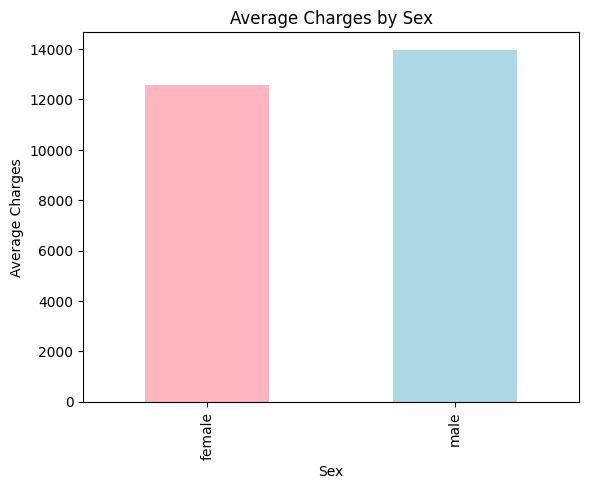

In [65]:
#used copilot suggestions to generate this code and label the graph
avg_charges.plot(kind='bar', color=['lightpink', 'lightblue'])
plt.xlabel('Sex')
plt.ylabel('Average Charges')
plt.title('Average Charges by Sex')
plt.show()

While males on average have slightly higher insurance costs, sex alone is not a big contributor to medical charges. The number of females and males in the data were quite similar from our value counts.

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
